## 1. Setup & Load Data

In [11]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Customer-Behavior-Analysis/'
RAW_PATH = BASE_PATH + 'data/raw/customer_shopping_behavior.csv'
CLEANED_PATH = BASE_PATH + 'data/cleaned/customer.csv'


import os
os.makedirs(BASE_PATH + 'data/cleaned', exist_ok=True)
os.makedirs(BASE_PATH + 'images', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [13]:
df_raw = pd.read_csv(RAW_PATH)   # Original dataset
df = df_raw.copy()                # Working copy
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [15]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


## 2. Handle Missing Values

In [16]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [17]:
# Review Rating has missing values — fill using the median rating
# within each product category (more accurate than a global median)
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)
df.isnull().sum()


,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


## 3. Standardize Column Names

In [18]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## 4. Feature Engineering

In [19]:
# Segment customers into quartile-based age groups
labels = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)
df[['age', 'age_group']].head(10)


,age,age_group
0,55,Middle Aged
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Aged


In [20]:
# Convert purchase frequency text into an approximate number of days
# NOTE: keys must match the dataset's exact text, including hyphenation
# ('Bi-Weekly', not 'Bi- Weekly') — mismatched keys silently produce NaN.
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

# Sanity check — should be zero
assert df['purchase_frequency_days'].isnull().sum() == 0, "Unmapped frequency values found!"
df[['frequency_of_purchases', 'purchase_frequency_days']].head(10)


,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


## 5. Drop Redundant Columns

In [21]:
# discount_applied and promo_code_used are identical in this dataset
(df['discount_applied'] == df['promo_code_used']).all()


np.True_

In [22]:
df = df.drop('promo_code_used', axis=1)
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

## 6. Export Cleaned Dataset

In [23]:
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset -> {CLEANED_PATH}")
print(f"Shape: {df.shape}")


Saved cleaned dataset -> /content/drive/MyDrive/Customer-Behavior-Analysis/data/cleaned/customer.csv
Shape: (3900, 19)


## 7. Exploratory Analysis & Key Insights





### Revenue by Gender

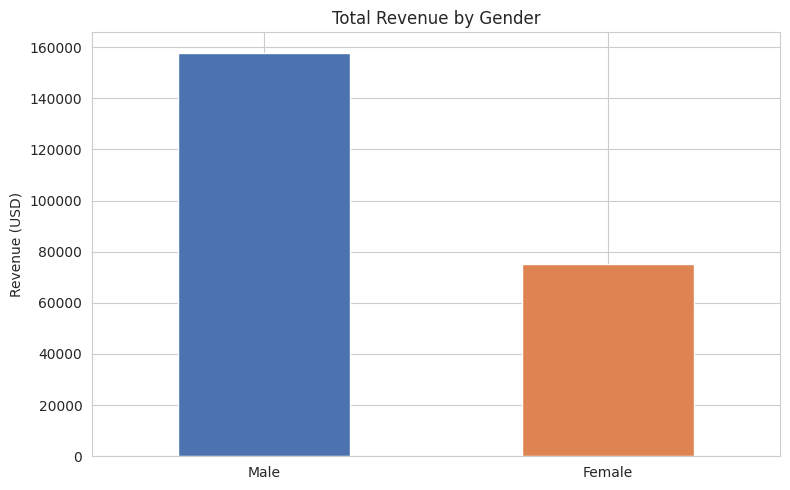

,purchase_amount
gender,
Male,157890
Female,75191


In [28]:
revenue_by_gender = df.groupby('gender')['purchase_amount'].sum().sort_values(ascending=False)

ax = revenue_by_gender.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Total Revenue by Gender')
ax.set_ylabel('Revenue (USD)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_PATH + '/images/revenue_by_gender.png', dpi=120)
plt.show()

revenue_by_gender


### Top 5 Products by Average Review Rating

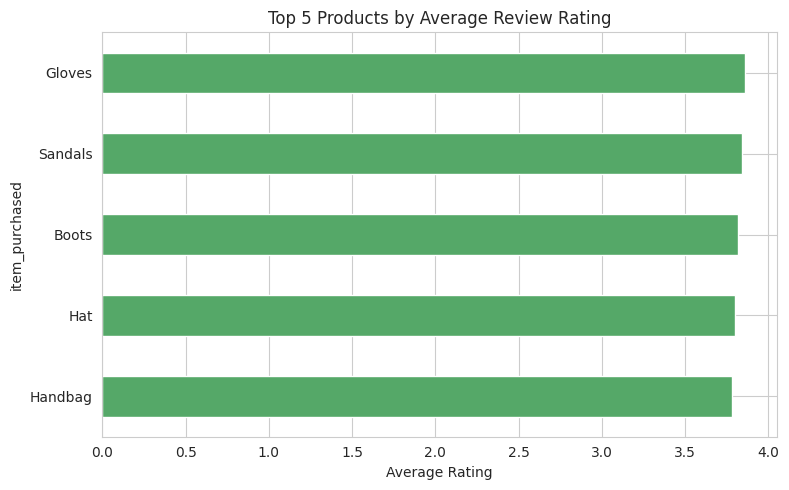

,review_rating
item_purchased,
Gloves,3.86
Sandals,3.84
Boots,3.82
Hat,3.80
Handbag,3.78


In [30]:
top_rated = (df.groupby('item_purchased')['review_rating']
               .mean()
               .round(2)
               .sort_values(ascending=False)
               .head(5))

ax = top_rated.plot(kind='barh', color='#55A868')
ax.invert_yaxis()
ax.set_title('Top 5 Products by Average Review Rating')
ax.set_xlabel('Average Rating')
plt.tight_layout()
plt.savefig(BASE_PATH + '/images/top5_rated_products.png', dpi=120)
plt.show()

top_rated


### Revenue Contribution by Age Group

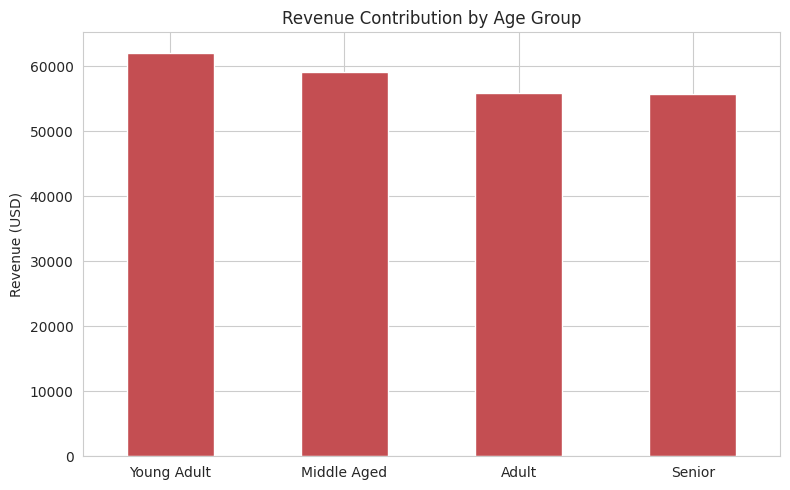

,purchase_amount
age_group,
Young Adult,62143
Middle Aged,59197
Adult,55978
Senior,55763


In [32]:
revenue_by_age = df.groupby('age_group', observed=True)['purchase_amount'].sum().sort_values(ascending=False)

ax = revenue_by_age.plot(kind='bar', color='#C44E52')
ax.set_title('Revenue Contribution by Age Group')
ax.set_ylabel('Revenue (USD)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_PATH + '/images/revenue_by_age_group.png', dpi=120)
plt.show()

revenue_by_age


### Subscribed vs. Non-Subscribed Spend

In [33]:
sub_summary = df.groupby('subscription_status')['purchase_amount'].agg(
    total_customers='count', avg_spend='mean', total_revenue='sum'
).round(2)
sub_summary


,total_customers,avg_spend,total_revenue
subscription_status,,,
No,2847,59.87,170436
Yes,1053,59.49,62645


**Insight:** Non-subscribed customers generate a higher total revenue and a
comparable average spend to subscribed customers in this dataset — subscription
status alone doesn't appear to drive higher individual spend.


### Discount Usage by Product (Top 5)

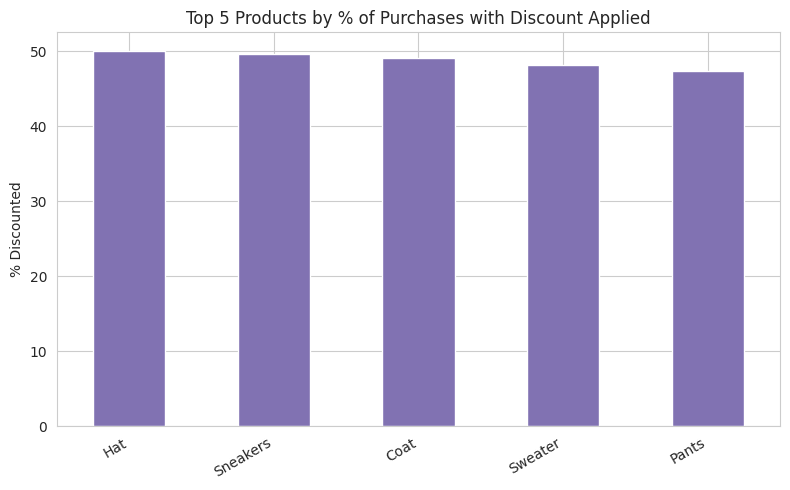

,discounted
item_purchased,
Hat,50.00
Sneakers,49.66
Coat,49.07
Sweater,48.17
Pants,47.37


In [34]:
discount_rate = (df.assign(discounted=(df['discount_applied'] == 'Yes').astype(int))
                    .groupby('item_purchased')['discounted']
                    .mean()
                    .mul(100)
                    .round(2)
                    .sort_values(ascending=False)
                    .head(5))

ax = discount_rate.plot(kind='bar', color='#8172B2')
ax.set_title('Top 5 Products by % of Purchases with Discount Applied')
ax.set_ylabel('% Discounted')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(BASE_PATH + '/images/top5_discounted_products.png', dpi=120)
plt.show()

discount_rate


### Customer Segments (New / Returning / Loyal)

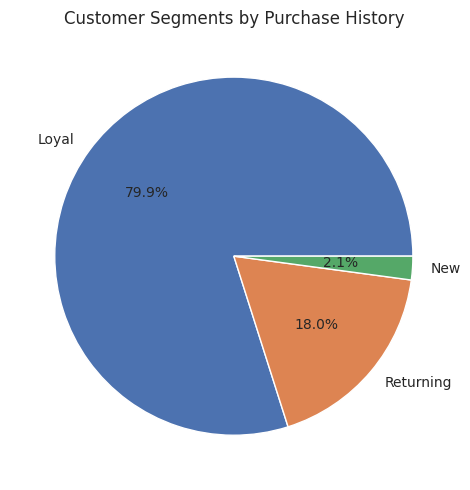

,count
previous_purchases,
Loyal,3116
Returning,701
New,83


In [37]:
def segment(p):
    if p == 1:
        return 'New'
    elif 2 <= p <= 10:
        return 'Returning'
    else:
        return 'Loyal'

segment_counts = df['previous_purchases'].apply(segment).value_counts()

ax = segment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('')
ax.set_title('Customer Segments by Purchase History')
plt.tight_layout()
plt.savefig(BASE_PATH + '/images/customer_segments.png', dpi=120)
plt.show()

segment_counts


## Summary of Findings

- **Gender:** Male customers generate roughly 2x the revenue of female customers.
- **Ratings:** Gloves, Sandals, and Boots have the highest average review ratings.
- **Age groups:** Revenue is fairly evenly distributed across age groups, with
  Young Adults contributing slightly more than Seniors.
- **Subscriptions:** Subscription status does **not** correlate with higher
  average spend — non-subscribers actually contribute more total revenue
  simply because there are more of them.
- **Discounts:** Hats, Sneakers, and Coats have the highest discount usage rates
  (~47-50% of purchases).
- **Customer loyalty:** The large majority of customers (80%) are "Loyal"
  (11+ previous purchases), suggesting strong repeat-purchase behavior overall.

See `sql/customer_behavior_queries.sql` for the full set of 10 business
questions answered in SQL against this cleaned dataset.
